## Load required packages

In [0]:
# import mlflow
# # Experiments are logged in shared workspace 
# mlflow.set_experiment("/Workspace/Shared/GeoX_Testing") 


In [0]:
import panel_exp
import os
import numpy as np
import pandas as pd
# from databricks import sql
import matplotlib.pyplot as plt
import seaborn as sns
# import multiprocessing
from sklearn.linear_model import RidgeCV, Ridge
from typing import Dict, List, NewType, Optional, Tuple, Union
from abc import ABCMeta
from datetime import datetime, timedelta
# from panel_exp.util import standardize

from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.methods.tbr import TBR, TBRRidge
from panel_exp.methods.bayesian_regression import BayesianTBR
from panel_exp.methods.scm import SyntheticControl, AugSynth
from panel_exp.design.power import PowerAnalysis
from panel_exp.design import StratifiedRandomization, CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock, MatchedPair, greedy_match_markets
from panel_exp.design.design_metrics import imbalance
from panel_exp.design.geo_experiment_design import GeoExperimentDesign
# from panel_exp.design.supergeos import SupergeoModel
from panel_exp.design.trimmed_match import TrimmedMatchDesign
from panel_exp.utils.test_designs_evaluation import *

## Load Spark functions and configurations

In [0]:
from pyspark import SparkContext, SparkConf , StorageLevel
from pyspark.sql import SparkSession, HiveContext
from pyspark.sql.functions import *
from pyspark.sql.types import *
import logging
from datetime import datetime,timedelta 
import json
from pyspark.sql import functions
import sys
import pytz

In [0]:
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 300)
pd.options.display.float_format = None


spark.sql('SET hive.groupby.orderby.position.alias=true')
spark.sql('SET hive.exec.dynamic.partition=true')
spark.sql('SET hive.exec.dynamic.partition.mode=nonstrict')
spark.sql('SET spark.sql.sources.partitionOverwriteMode=dynamic')
# spark.conf.set("spark.databricks.queryWatchdog.maxQueryTasks", "4000")

#DELTA OPTIMIZATIONS
spark.sql('SET spark.databricks.delta.autoCompact.enabled=auto')
spark.sql('SET spark.databricks.delta.optimizeWrite.enabled=true')
spark.sql('SET spark.sql.shuffle.partitions=auto')

DataFrame[key: string, value: string]

## Fetch last 12 months of Sales and Conversions data from pivot table. 
If working with a different dataset (e.g., BSV, Site Visits, Installs, etc.), ensure the final output is condensed to include only the following columns: date, geo, and {kpi}.

In [0]:
us_sales_l12m = spark.sql("""
     select date
     , geo 
     , cc_segment
     , sum(response1) as sales 
     , sum(response2) as conversions 
from gmi_im.us_dme_sales_l12m
where cc_segment is not null
--and geo != '?'
group by 1,2,3
""").toPandas()

**Sales and Conversions data for other countries can be found in the following [location](https://adb-4386671392973777.17.azuredatabricks.net/browse/folders/4037357942322583?o=4386671392973777).** 
> **Note:** In the US, the `geo` column contains **DMA IDs**. For countries outside the US, it may include more granular values such as **cities**. The `geo` column follows the format: `<country:state:city>`.  
Please ensure the data is **rolled up** to a level that aligns with **platform targeting capabilities**.

In [0]:
us_sales_l12m.head()

,date,geo,cc_segment,sales,conversions
0,2025-11-01,504,ACROBAT DC,17472.840000,87
1,2025-11-05,819,ACROBAT DC,17418.194739,100
2,2025-11-05,811,ACROBAT CC,3958.440000,13
3,2024-12-01,524,STUDENT,5893.970000,30
4,2025-03-29,504,ACROBAT CC,31474.080000,115


In [0]:
#Logging raw data with ML flow for reproducibility
import uuid

mlflow.end_run()
mlflow.start_run(run_name=f"geox_design_analysis_{uuid.uuid4().hex[:8]}")
    
# Log a parameter
mlflow.log_param("data_size", len(us_sales_l12m))
mlflow.log_param("total_sales", us_sales_l12m.sales.sum().round())
mlflow.log_param("total_conversions", us_sales_l12m.conversions.sum().round())

# Log the file as an artifact
us_sales_l12m.to_json("us_sales_l12m_full.json", orient="records", lines=True)
mlflow.log_artifact(local_path="us_sales_l12m_full.json", artifact_path="us_sales_l12m")

print(f"Logged entire dataset with {len(us_sales_l12m)} rows")


Logged entire dataset with 465911 rows


In [0]:
# Segmenting overall sales data by category: DME, CC, and DC.

cc= ['TEAM', 'STOCK', 'HED',  'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'STUDENT']

dc = [ 'ACROBAT DC',  'ACROBAT CC' ]

all_segment = ['TEAM', 'STOCK', 'HED', 'ACROBAT DC', 'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'ACROBAT CC', 'PDF SERVICES', 'SIGN', 'STUDENT']

dme = ['TEAM', 'STOCK', 'HED', 'ACROBAT DC', 'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'ACROBAT CC', 'STUDENT']


us_dme_sales_l12m = us_sales_l12m[us_sales_l12m.cc_segment.isin(dme)].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()

us_dc_sales_l12m = us_sales_l12m[us_sales_l12m.cc_segment.isin(dc)].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()

us_cc_sales_l12m = us_sales_l12m[us_sales_l12m.cc_segment.isin(cc)].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()


print(f'''us_dme_sales_l12m: {us_dme_sales_l12m.sales.sum().round()}, us_dc_sales_l12m: {us_dc_sales_l12m.sales.sum().round()}, us_cc_sales_l12m: {us_cc_sales_l12m.sales.sum().round()} ''')


us_dme_sales_l12m: 1753227941.0, us_dc_sales_l12m: 924998375.0, us_cc_sales_l12m: 828229566.0 


In [0]:
us_cc_sales_l12m.head()

,date,geo,sales,conversions
0,2024-09-24,500,4292.310000,15
1,2024-09-24,501,191393.134904,541
2,2024-09-24,502,1169.520000,4
3,2024-09-24,503,1127.400000,5
4,2024-09-24,504,43543.277840,125


## Test Design Function: Create Multiple Test Groups with Whitelist and Blacklist functionality

In [0]:
## Required Parameters
n_test_grps = 2                        # Number of test groups to create
kpi = 'conversions'                    # KPI column name
data = {'dme': us_dme_sales_l12m, 'dc': us_dc_sales_l12m, 'cc': us_cc_sales_l12m}['dme']
data['geo'] = data['geo'].astype('str')


## Optional Parameters
treatment_probability = [None,0.10,0.20,0.30,0.40,0.50][0]              #Probability of assigning each geo to the test group
test_lengths = [42,56]             # can pass multiple test lengths, default is [28, 56, 91] i.e. [4weeks, 8weeks, 13weeks]
# n_sample_prc = 0.2                  # percentage of data to sample for power analysis, smaller for faster run times

# List of design algorithms available for selection
base_cls = [StratifiedRandomization, CompleteRandomization, ThinningDesign, QuickBlock, greedy_match_markets][-1]

# Specify geos to include (whitelist) or exclude (blacklist) from test design
test_whitelist = []
test_blacklist = []
control_whitelist = []
control_blacklist = []
control_test_blacklist = []


In [0]:

with mlflow.start_run(run_name="test_design_shortlist", nested=True):
    #mlflow logging
    if 'n_test_grps' in locals(): mlflow.log_param("n_test_grps", n_test_grps)
    if 'treatment_probability' in locals(): mlflow.log_param("treatment_probability", treatment_probability)
    if 'kpi' in locals(): mlflow.log_param("kpi", kpi)
    if 'base_cls' in locals(): mlflow.log_param("base_cls", base_cls.__name__ if hasattr(base_cls, "__name__") else str(base_cls))
    if 'test_whitelist' in locals(): mlflow.log_param("test_whitelist", str(test_whitelist))
    if 'test_blacklist' in locals(): mlflow.log_param("test_blacklist", str(test_blacklist))
    if 'control_whitelist' in locals(): mlflow.log_param("control_whitelist", str(control_whitelist))
    if 'control_blacklist' in locals(): mlflow.log_param("control_blacklist", str(control_blacklist))
    if 'control_test_blacklist' in locals(): mlflow.log_param("control_test_blacklist", str(control_test_blacklist))
    if 'n_sample_prc' in locals(): mlflow.log_param("n_sample_prc", n_sample_prc)
    if 'test_lengths' in locals(): mlflow.log_param("test_lengths", str(test_lengths))

    #Design logic
    import warnings
    warnings.filterwarnings('ignore')

    panel_dataset = long_df_to_paneldataset(data, "date", "geo", kpi)
    panel_dataset.wide_data = panel_dataset.wide_data.fillna(0)

    mde_percent_df = pd.DataFrame()
    mde_absolute_df = pd.DataFrame()
    power_analysis_results_df = pd.DataFrame()

    ged = GeoExperimentDesign(panel_data=panel_dataset,
                              n_test_grps=n_test_grps,
                              treatment_probability=treatment_probability,
                              test_whitelist=test_whitelist,
                              control_whitelist=control_whitelist,
                              test_blacklist=test_blacklist,
                              control_blacklist=control_blacklist,
                              control_test_blacklist=control_test_blacklist,
                              base_randomizer_cls=base_cls,
                            #   n_sample_prc = n_sample_prc,
                              ci_version = 2,  
                              test_lengths = test_lengths
                            )

    for _ in range(5):  #run this loop multiple times to get potential design candidates
        mde_prcs, mde_vals, pa_obj = ged.run_design()
        mde_percent_df = pd.concat([mde_percent_df, mde_prcs])
        mde_absolute_df = pd.concat([mde_absolute_df, mde_vals])
        power_analysis_results_df = pd.concat([power_analysis_results_df, pa_obj])
    
    mlflow.log_table(mde_percent_df, "mde_percent_df.json")
    mlflow.log_table(mde_absolute_df, "mde_absolute_df.json")
    mlflow.log_table(power_analysis_results_df, "power_analysis_results_df.json")


In [0]:
# import pandas as pd
# import json

# # Load the JSON data properly
# with open('/Workspace/Users/ppavuluri@adobe.com/Data/power_analysis_results_df.json', 'r') as f:
#     data = json.load(f)

# # Create DataFrame from the structure
# columns = data['columns']
# rows = data['data']

# # Convert to DataFrame
# power_analysis_results_df = pd.DataFrame(rows, columns=columns)

# # Load the JSON data properly
# with open('/Workspace/Users/ppavuluri@adobe.com/Data/mde_percent_df.json', 'r') as f:
#     data = json.load(f)

# # Create DataFrame from the structure
# columns = data['columns']
# rows = data['data']

# # Convert to DataFrame
# mde_percent_df = pd.DataFrame(rows, columns=columns)

# # Load the JSON data properly
# with open('/Workspace/Users/ppavuluri@adobe.com/Data/mde_absolute_df.json', 'r') as f:
#     data = json.load(f)

# # Create DataFrame from the structure
# columns = data['columns']
# rows = data['data']

# # Convert to DataFrame
# mde_absolute_df = pd.DataFrame(rows, columns=columns)

In [0]:
# MDE estimates: each row represents a test-control group combination.
# Rows are grouped in sets of `n_test_grps`, where each group corresponds to a single design.
# For example, if n_test_grps = 2, the first two rows represent two test groups sharing a common control.
mde_percent_df

,4wk_percent,6wk_percent,8wk_percent,control_dmas,test_dmas,test_prc,control_prc
0,0.01,0.01,0.01,"[705, 724, 552, 524, 638, 500, 550, 651, 686, ...","[743, 511, 570, 592, 561, 583, 757, 513, 656, ...",32.93,31.09
1,0.01,0.01,0.01,"[705, 724, 552, 524, 638, 500, 550, 651, 686, ...","[661, 687, 610, 736, 567, 502, 543, 702, 868, ...",29.46,31.09
2,0.02,0.01,0.01,"[529, 517, 821, 537, 507, 523, 756, 625, 543, ...","[804, 718, 596, 758, 598, 560, 553, 564, 698, ...",33.29,33.32
3,0.01,0.01,0.01,"[529, 517, 821, 537, 507, 523, 756, 625, 543, ...","[709, 506, 650, 542, 522, 502, 636, 561, 855, ...",26.85,33.32
4,0.02,0.01,0.01,"[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[718, 519, 575, 511, 584, 605, 574, 559, 501, ...",33.33,33.30
5,0.02,0.01,0.01,"[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[564, 502, 516, 596, 610, 658, 543, 550, 764, ...",29.93,33.30
6,0.01,0.01,0.01,"[557, 819, 737, 740, 503, 825, 734, 529, 521, ...","[624, 630, 541, 598, 813, 532, 641, 505, 561, ...",30.20,33.30
7,0.01,0.01,0.01,"[557, 819, 737, 740, 503, 825, 734, 529, 521, ...","[820, 609, 718, 582, 758, 577, 553, 807, 687, ...",26.24,33.30
8,0.01,0.01,0.01,"[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[636, 551, 577, 811, 803, 647, 552, 584, 617, ...",33.31,33.30
9,0.01,0.01,0.01,"[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[678, 722, 866, 565, 566, 534, 630, 627, 546, ...",30.23,33.30


In [0]:
mde_absolute_df

,4wk_val,6wk_val,8wk_val,control_dmas,test_dmas,test_prc,control_prc
0,1671.159144,2086.884680,2783.002527,"[705, 724, 552, 524, 638, 500, 550, 651, 686, ...","[743, 511, 570, 592, 561, 583, 757, 513, 656, ...",32.93,31.09
1,1543.471548,2034.507762,2731.465579,"[705, 724, 552, 524, 638, 500, 550, 651, 686, ...","[661, 687, 610, 736, 567, 502, 543, 702, 868, ...",29.46,31.09
2,2200.479532,2938.172225,3718.643220,"[529, 517, 821, 537, 507, 523, 756, 625, 543, ...","[804, 718, 596, 758, 598, 560, 553, 564, 698, ...",33.29,33.32
3,1337.656173,1676.161321,2397.020273,"[529, 517, 821, 537, 507, 523, 756, 625, 543, ...","[709, 506, 650, 542, 522, 502, 636, 561, 855, ...",26.85,33.32
4,2099.680796,2744.487183,3269.153376,"[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[718, 519, 575, 511, 584, 605, 574, 559, 501, ...",33.33,33.30
5,1898.173695,2291.247706,2649.867332,"[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[564, 502, 516, 596, 610, 658, 543, 550, 764, ...",29.93,33.30
6,1549.851872,2082.006395,2907.982418,"[557, 819, 737, 740, 503, 825, 734, 529, 521, ...","[624, 630, 541, 598, 813, 532, 641, 505, 561, ...",30.20,33.30
7,1515.743489,2062.565443,2771.154218,"[557, 819, 737, 740, 503, 825, 734, 529, 521, ...","[820, 609, 718, 582, 758, 577, 553, 807, 687, ...",26.24,33.30
8,1544.550921,2468.031803,2698.737252,"[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[636, 551, 577, 811, 803, 647, 552, 584, 617, ...",33.31,33.30
9,1412.181723,2069.175802,2452.250366,"[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[678, 722, 866, 565, 566, 534, 630, 627, 546, ...",30.23,33.30


In [0]:
power_analysis_results_df

,4wk_pa_obj1,6wk_pa_obj1,8wk_pa_obj1,4wk_pa_obj2,6wk_pa_obj2,8wk_pa_obj2,control_dmas,test_dmas,test_prc,control_prc
0,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[705, 724, 552, 524, 638, 500, 550, 651, 686, ...","[743, 511, 570, 592, 561, 583, 757, 513, 656, ...",32.93,31.09
1,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[705, 724, 552, 524, 638, 500, 550, 651, 686, ...","[661, 687, 610, 736, 567, 502, 543, 702, 868, ...",29.46,31.09
2,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[529, 517, 821, 537, 507, 523, 756, 625, 543, ...","[804, 718, 596, 758, 598, 560, 553, 564, 698, ...",33.29,33.32
3,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[529, 517, 821, 537, 507, 523, 756, 625, 543, ...","[709, 506, 650, 542, 522, 502, 636, 561, 855, ...",26.85,33.32
4,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[718, 519, 575, 511, 584, 605, 574, 559, 501, ...",33.33,33.30
5,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[564, 502, 516, 596, 610, 658, 543, 550, 764, ...",29.93,33.30
6,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[557, 819, 737, 740, 503, 825, 734, 529, 521, ...","[624, 630, 541, 598, 813, 532, 641, 505, 561, ...",30.20,33.30
7,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[557, 819, 737, 740, 503, 825, 734, 529, 521, ...","[820, 609, 718, 582, 758, 577, 553, 807, 687, ...",26.24,33.30
8,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[636, 551, 577, 811, 803, 647, 552, 584, 617, ...",33.31,33.30
9,"{'columns'

# Re-running shortlisted designs from above with ci_version = 1 for more conservative MDE estimates

In [0]:
def get_shortlisted_designs_for_duration(mde_percent_df, duration_str, n_test_grps, top_pct=0.2):
    """
    Returns the row indices for the best designs for the given duration,
    using the create_design_summary function for scoring.
    
    Parameters:
    -----------
    mde_percent_df : pandas.DataFrame
        DataFrame containing MDE and balance metrics
    duration_str : str
        Test length string (e.g., '4wk', '8wk')
    n_test_grps : int
        Number of test groups per design
    top_pct : float
        Percentage of top designs to return (default: 0.2 for top 20%)
    
    Returns:
    --------
    list of lists
        Each inner list contains the row indices for a design's test groups
    """
    # Calculate number of designs
    n_designs = len(mde_percent_df) // n_test_grps
    
    # Create design summary DataFrame
    design_summary = pd.DataFrame({
        'design_id': [i for i in range(n_designs) for _ in range(n_test_grps)],
        'test_group': [j for _ in range(n_designs) for j in range(n_test_grps)]
    })
    
    # Add metrics from mde_percent_df
    design_summary[f'mde_percent_{duration_str}'] = mde_percent_df[f'{duration_str}_percent'].values
    design_summary['test_group_percentage'] = mde_percent_df['test_prc'].values
    design_summary['control_group_percentage'] = mde_percent_df['control_prc'].values
    
    # Use existing create_design_summary function
    summary = create_design_summary(design_summary, duration_str)
    
    # Sort by combined score and get top designs
    summary = summary.sort_values(f'combined_score_{duration_str}', ascending=False)
    n_top = builtins.max(1, int(len(summary) * top_pct))
    top_designs = summary.head(n_top)
    
    # Get the row indices for each top design
    best_design_indices = []
    for design_id in top_designs['design_id']:
        design_rows = design_summary[design_summary['design_id'] == design_id].index.tolist()
        best_design_indices.append(design_rows)
    
    return best_design_indices

In [0]:
# indexes is a list of lists, where each inner list represents a design candidate
# For example: indexes = [[0, 1], [2, 3], [4, 5]] where each pair represents a test-control group combination
indexes = get_shortlisted_designs_for_duration(mde_percent_df, '8wk', n_test_grps=n_test_grps, top_pct=0.6)
print(f'Shortlisted indices for power analysis and conservative MDE estimation: {indexes}')

Shortlisted indices for power analysis and conservative MDE estimation: [[0, 1], [8, 9], [4, 5]]


In [0]:
import ast
import builtins

# Initialize empty DataFrames to store results
mde_prc_df2 = pd.DataFrame()
mde_val_df2 = pd.DataFrame()
pa_df_combined = pd.DataFrame()

with mlflow.start_run(run_name="power_analysis_for_shortlisted_designs", nested=True):
    # Log key parameters
    mlflow.log_param("test_lengths", test_lengths)
    mlflow.log_param("kpi", kpi)

    # Loop over each design candidate (each inner list)
    for design_idx, design_candidate in enumerate(indexes):
        # Start a nested run for each design candidate
        with mlflow.start_run(run_name=f"design_candidate_{design_idx}", nested=True):
            # Log design identifier
            mlflow.log_param("design_id", design_idx)
            mlflow.log_param("design_candidate_indices", design_candidate)
            
            # Get control group (same for all test groups in this design)
            control = mde_percent_df.reset_index().loc[design_candidate[0], 'control_dmas']
            
            # Process each test group in the design candidate
            for test_group_idx in design_candidate:
                # Get test group
                test = mde_percent_df.reset_index().loc[test_group_idx, 'test_dmas']
                
                # Prepare panel dataset for this test-control combination
                panel_dataset = long_df_to_paneldataset(
                    data[data.geo.isin(test + control)], "date", "geo", kpi, treated_units=test
                )
                panel_dataset.wide_data = panel_dataset.wide_data.fillna(0)

                ## Run the power analysis
                mde_val_df_tmp, mde_prc_df_tmp, pa_obj1, pa_obj2 = GeoExperimentDesign(
                    panel_data=panel_dataset,
                    ci_version=1,
                    n_sample_prc=0.1,
                    test_lengths=test_lengths
                )._run_power_analysis()

                # Append test and control groups to the temporary DataFrames
                mde_prc_df_tmp.extend([control, test])
                mde_val_df_tmp.extend([control, test])

                # Dynamically create columns based on test_lengths for pa_obj1 and pa_obj2
                columns_mde = [f"{int(length / 7)}wk_percent" for length in test_lengths] + ['control_dmas', 'test_dmas']
                columns_pa = [f"{int(length / 7)}wk_pa_obj1" for length in test_lengths] + \
                            [f"{int(length / 7)}wk_pa_obj2" for length in test_lengths] + \
                            ['control_dmas', 'test_dmas']

                mde_prc_df_tmp = pd.DataFrame([mde_prc_df_tmp], columns=columns_mde, index=[design_idx])
                mde_val_df_tmp = pd.DataFrame([mde_val_df_tmp], columns=columns_mde, index=[design_idx])
                
                mde_prc_df2 = pd.concat([mde_prc_df2, mde_prc_df_tmp], axis=0)
                mde_val_df2 = pd.concat([mde_val_df2, mde_val_df_tmp], axis=0)

                # Extract the values from pa_obj1 and pa_obj2 for each test length
                pa_obj1_list = [pa_obj1[length] for length in test_lengths]
                pa_obj2_list = [pa_obj2[length] for length in test_lengths]
                # Combine pa_obj1 and pa_obj2
                pa_df_tmp = pd.DataFrame([pa_obj1_list + pa_obj2_list + [control, test]], columns=columns_pa, index=[design_idx])              

                pa_df_combined = pd.concat([pa_df_combined, pa_df_tmp], axis=0)
                pa_df_combined = pa_df_combined.sort_index()

                # Calculate the test and control percentages
                mde_prc_df2['test_prc'] = mde_prc_df2['test_dmas'].apply(
                    lambda x: np.round(data[data.geo.isin(x)][kpi].sum() * 100 / data[kpi].sum(), 2)
                )
                mde_prc_df2['control_prc'] = mde_prc_df2['control_dmas'].apply(
                    lambda x: np.round(data[data.geo.isin(x)][kpi].sum() * 100 / data[kpi].sum(), 2)
                )

                mde_val_df2['test_prc'] = mde_val_df2['test_dmas'].apply(
                    lambda x: np.round(data[data.geo.isin(x)][kpi].sum() * 100 / data[kpi].sum(), 2)
                )
                mde_val_df2['control_prc'] = mde_val_df2['control_dmas'].apply(
                    lambda x: np.round(data[data.geo.isin(x)][kpi].sum() * 100 / data[kpi].sum(), 2)
                )

                pa_df_combined['test_prc'] = pa_df_combined['test_dmas'].apply(
                    lambda x: np.round(data[data.geo.isin(x)][kpi].sum() * 100 / data[kpi].sum(), 2)
                )
                pa_df_combined['control_prc'] = pa_df_combined['control_dmas'].apply(
                    lambda x: np.round(data[data.geo.isin(x)][kpi].sum() * 100 / data[kpi].sum(), 2)
                )

                ## Log metrics for this test group
                for i, test_length in enumerate(test_lengths):
                    week_str = f"{int(test_length/7)}wk"
                    
                    # MDE Percentages 
                    mde_percent = mde_prc_df_tmp[week_str+"_percent"].iloc[0]
                    mlflow.log_metric(f"mde_percent_{week_str}_test_{test_group_idx}", mde_percent)
                    
                    # Absolute MDE Values 
                    mde_absolute = mde_val_df_tmp[week_str+"_percent"].iloc[0]
                    mlflow.log_metric(f"mde_absolute_{week_str}_test_{test_group_idx}", mde_absolute)
                    
                    # Power Analysis
                    power_data = pa_obj2[test_length]
                    if isinstance(power_data, pd.DataFrame):
                        # Log effect size needed for 80% power
                        power_80 = power_data[power_data['power'] >= 0.8]['prc_effect'].min()
                        mlflow.log_metric(f"effect_size_at_80pct_power_{week_str}_test_{test_group_idx}", power_80)

                # Log group balance metrics for this test group using existing percentages
                test_prc = mde_percent_df.reset_index().loc[test_group_idx, 'test_prc']
                control_prc = mde_percent_df.reset_index().loc[test_group_idx, 'control_prc']
                
                mlflow.log_metric(f"test_group_percentage_test_{test_group_idx}", test_prc)
                mlflow.log_metric(f"control_group_percentage_test_{test_group_idx}", control_prc)
                
                # Log design characteristics
                mlflow.log_metric(f"num_test_dmas_test_{test_group_idx}", len(test))
                mlflow.log_metric(f"num_control_dmas_test_{test_group_idx}", len(control))

            # Log the tables for detailed analysis
            mlflow.log_table(mde_prc_df2, "mde_prc_df2.json")
            mlflow.log_table(mde_val_df2, "mde_val_df2.json")
            mlflow.log_table(pa_df_combined, "pa_df_combined.json")


## Comparison Dashboard: Highlights Best Design After Processing all Designs. Check "Experiments >> geox_test_design >> design_comparison_dashboard"

In [0]:
import pandas as pd
import json

# Load the JSON data properly
with open('/Workspace/Users/ppavuluri@adobe.com/Data/pa_df_combined.json', 'r') as f:
    data = json.load(f)

# Create DataFrame from the structure
columns = data['columns']
rows = data['data']

# Convert to DataFrame
pa_df_combined = pd.DataFrame(rows, columns=columns)

# Load the JSON data properly
with open('/Workspace/Users/ppavuluri@adobe.com/Data/mde_prc_df2.json', 'r') as f:
    data = json.load(f)

# Create DataFrame from the structure
columns = data['columns']
rows = data['data']

# Convert to DataFrame
mde_percent_df = pd.DataFrame(rows, columns=columns)

# Load the JSON data properly
with open('/Workspace/Users/ppavuluri@adobe.com/Data/mde_val_df2.json', 'r') as f:
    data = json.load(f)

# Create DataFrame from the structure
columns = data['columns']
rows = data['data']

# Convert to DataFrame
mde_absolute_df = pd.DataFrame(rows, columns=columns)

In [0]:
# mde_prc_df2.rename(columns={'4wk':'4wk_percent','6wk':'6wk_percent','8wk':'8wk_percent'}, inplace=True)

In [0]:
mde_prc_df2

,6wk_percent,8wk_percent,control_dmas,test_dmas,test_prc,control_prc
0,-0.02,-0.02,"[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[636, 551, 577, 811, 803, 647, 552, 584, 617, ...",33.31,33.3
1,-0.02,-0.02,"[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[678, 722, 866, 565, 566, 534, 630, 627, 546, ...",30.23,33.3
2,-0.04,-0.02,"[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[718, 519, 575, 511, 584, 605, 574, 559, 501, ...",33.33,33.3
3,-0.02,-0.02,"[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[564, 502, 516, 596, 610, 658, 543, 550, 764, ...",29.93,33.3


In [0]:
pa_df_combined

,6wk_pa_obj1,8wk_pa_obj1,6wk_pa_obj2,8wk_pa_obj2,control_dmas,test_dmas,test_prc,control_prc
0,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[636, 551, 577, 811, 803, 647, 552, 584, 617, ...",33.31,33.3
1,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[527, 592, 625, 602, 638, 634, 657, 691, 825, ...","[678, 722, 866, 565, 566, 534, 630, 627, 546, ...",30.23,33.3
2,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[718, 519, 575, 511, 584, 605, 574, 559, 501, ...",33.33,33.3
3,"{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['Model', 'Inference', 'Test Lengt...","{'columns': ['prc_effect', 'power'], 'index': ...","{'columns': ['prc_effect', 'power'], 'index': ...","[611, 866, 710, 711, 560, 635, 536, 644, 678, ...","[564, 502, 516, 596, 610, 658, 543, 550, 764, ...",29.93,33.3


In [0]:
# Use .at for scalar assignment to a DataFrame cell
def convert_nested_dicts_to_dataframes(df, columns_to_convert):
    """
    Convert nested dictionary structures in DataFrame columns to actual DataFrames.
    """
    for col_str in columns_to_convert:
        if col_str in df.columns:
            for idx in range(len(df)):
                cell_value = df.at[idx, col_str]
                if isinstance(cell_value, dict) and 'data' in cell_value:
                    df.at[idx, col_str] = pd.DataFrame(
                        data=cell_value["data"],
                        index=cell_value.get("index", None),
                        columns=cell_value["columns"]
                    )
    return df

# Apply the conversion
pa_df_combined = convert_nested_dicts_to_dataframes(pa_df_combined, [col for col in pa_df_combined.columns if 'pa' in col])

In [0]:
pip install tabulate

Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.


In [0]:
# Design Comparison Dashboard
# --------------------------
# Creates comprehensive comparison of test designs across different test lengths:
# 1. Analyzes power, MDE and balance metrics for each design
# 2. Generates visualizations (heatmaps, power curves, radar charts) and summary reports
# 3. Returns summary table and test length comparison for design selection

# In databricks you can view the mlflow results under experiment runs, on local machine you can view the results by running mlflow ui --backend-store-uri file:{local_path to mlflow tracking file} --port 5000

summary_table, test_length_comparison = create_design_comparison_dashboard(
    pa_df_combined,     # DataFrame containing power analysis results
    mde_prc_df2,        # DataFrame containing MDE and balance metrics 
    test_lengths,       # List or array of test lengths (e.g., in days)
    n_test_grps         # Number of test groups per design
)

## Evaluate pre-test fit of test designs through cross-validation 

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/panel_exp/utils/test_designs_evaluation.py:1585: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  train_data = panel_data.wide_data.loc[:, panel_data.wide_data.columns.isin(train_dates)]
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/panel_exp/utils/test_designs_evaluation.py:1586: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  test_data = panel_data.wide_data.loc[:, panel_data.wide_data.columns.isin(test_dates)]
/local_disk0/.ephemeral_nfs/cluster_libraries/python/l

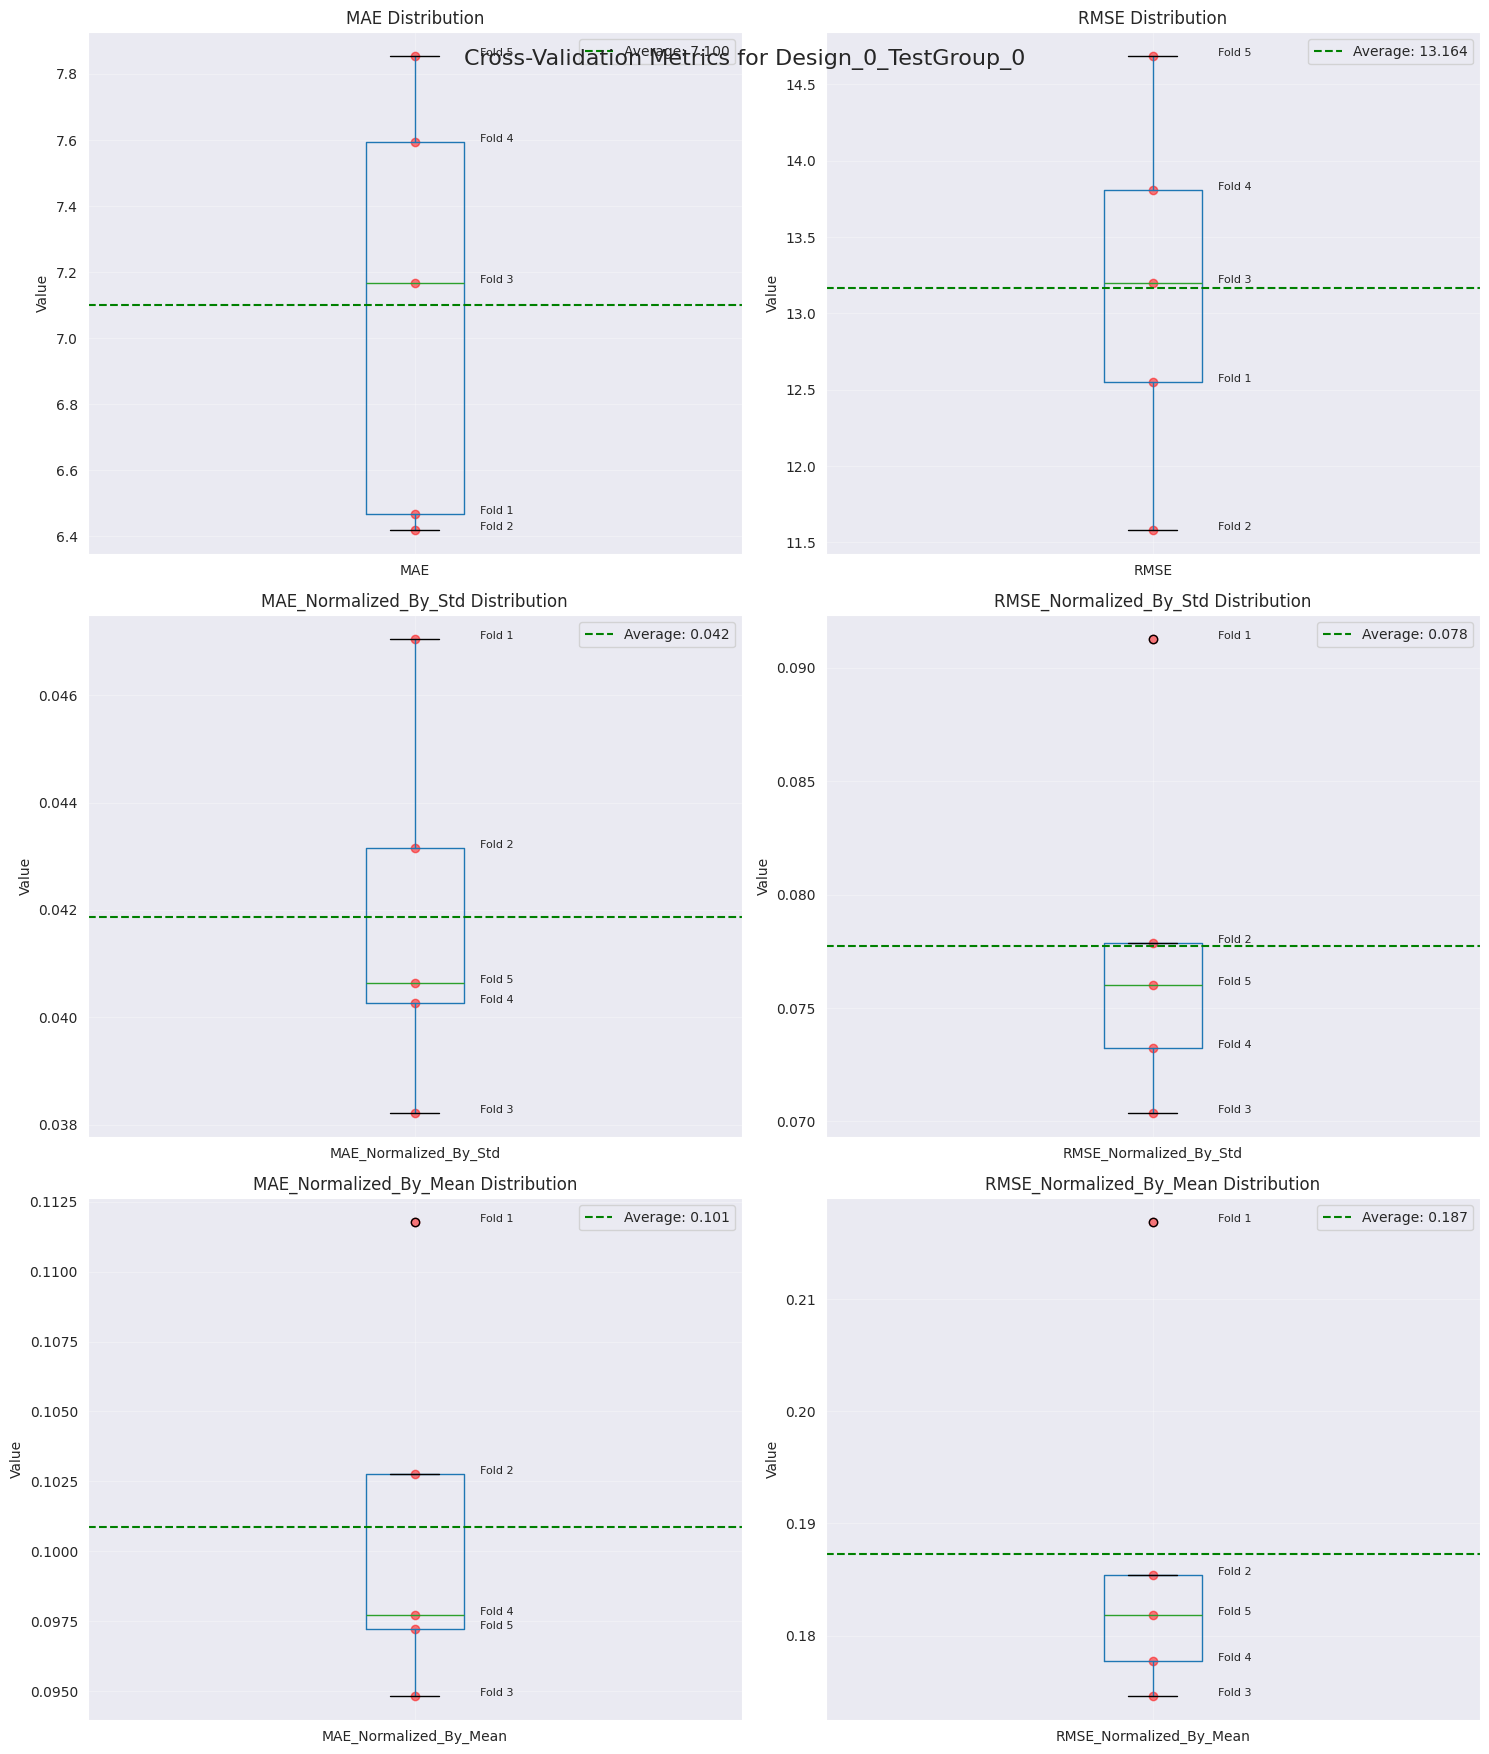

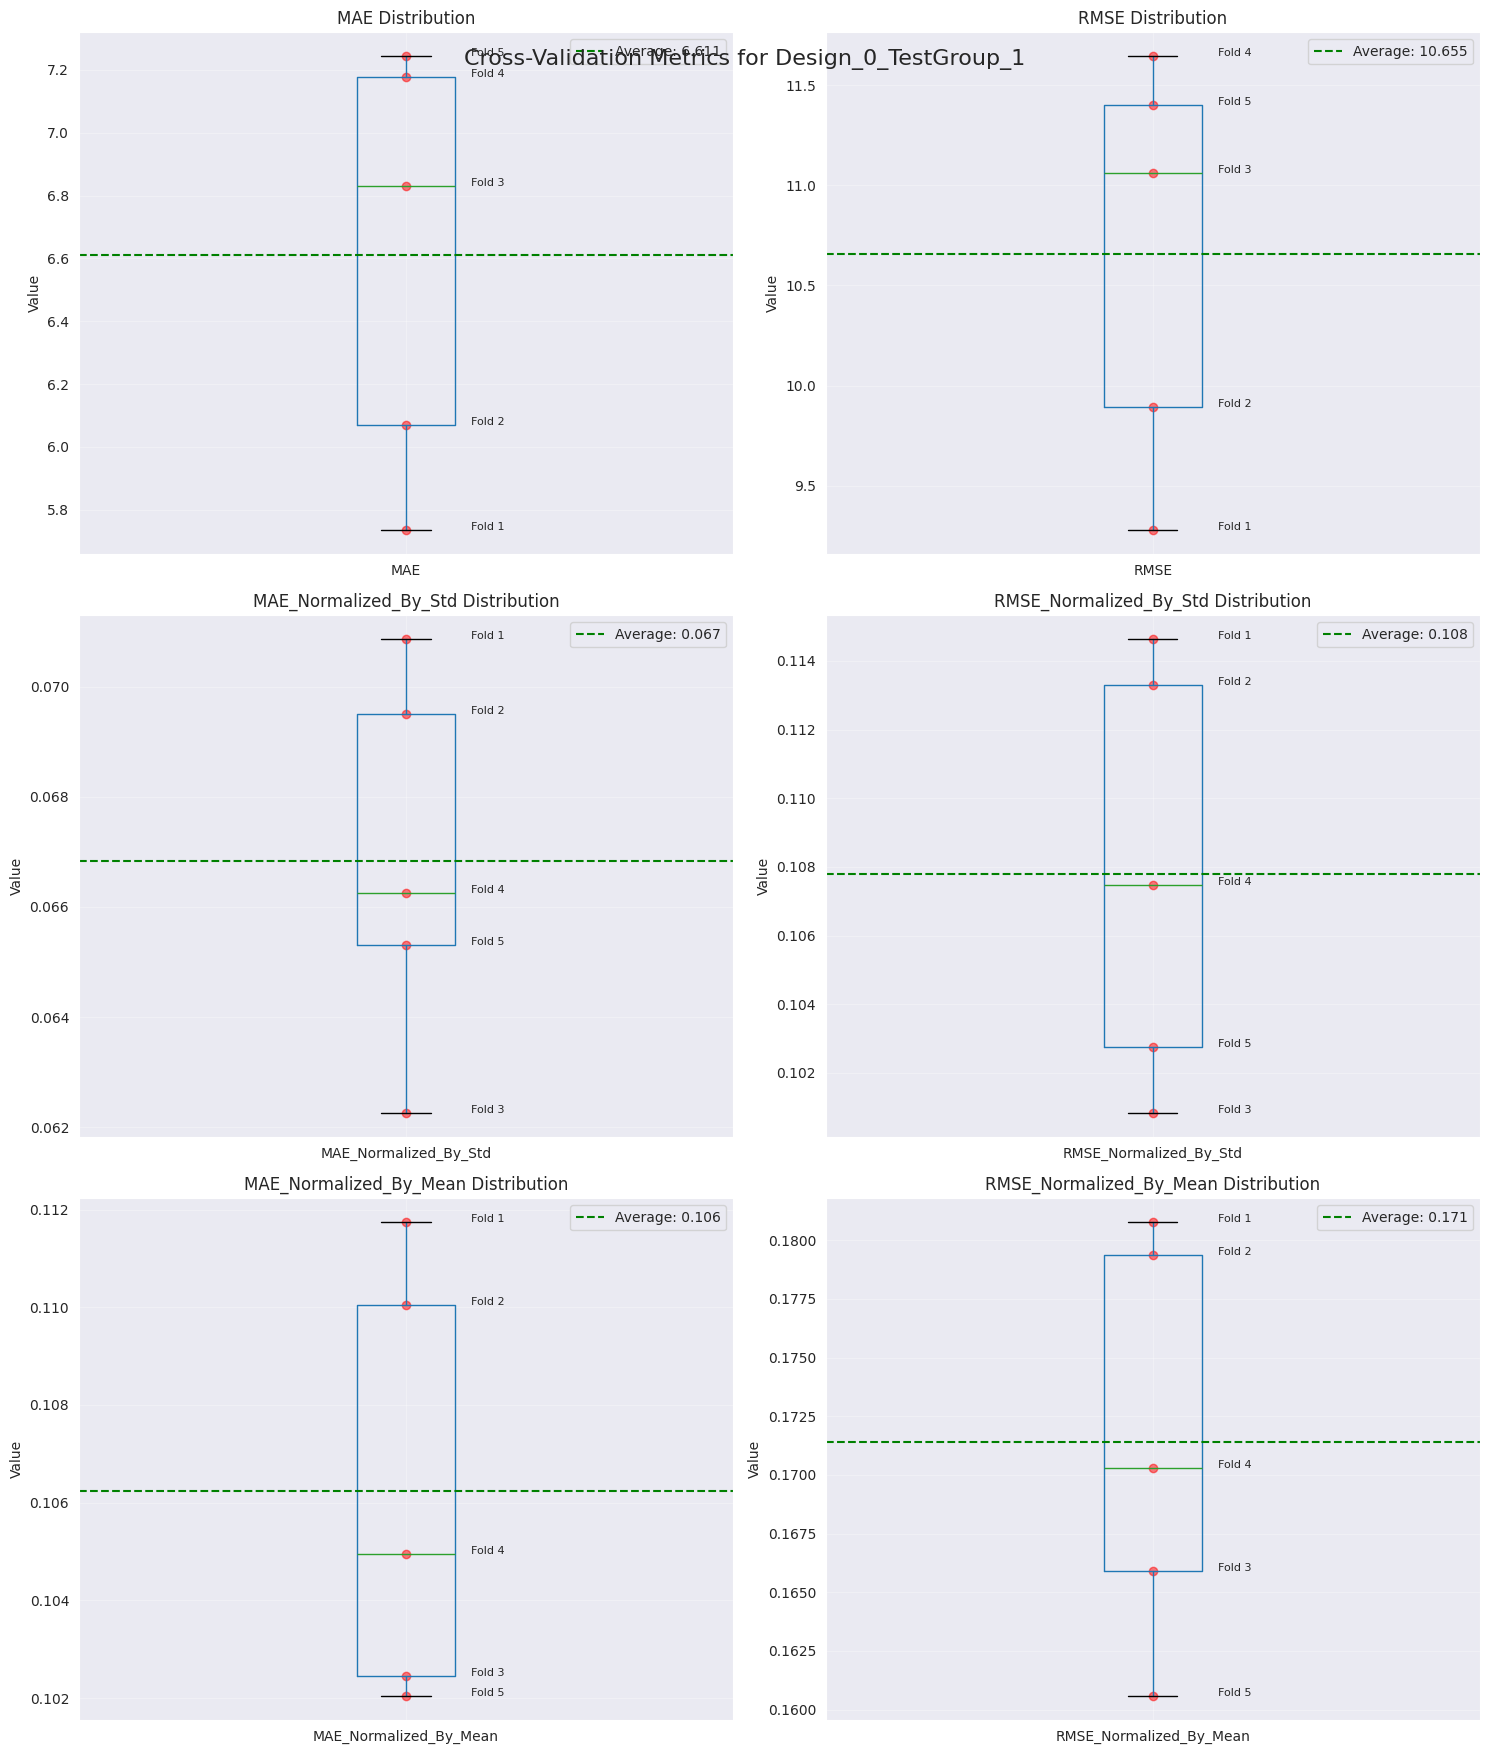

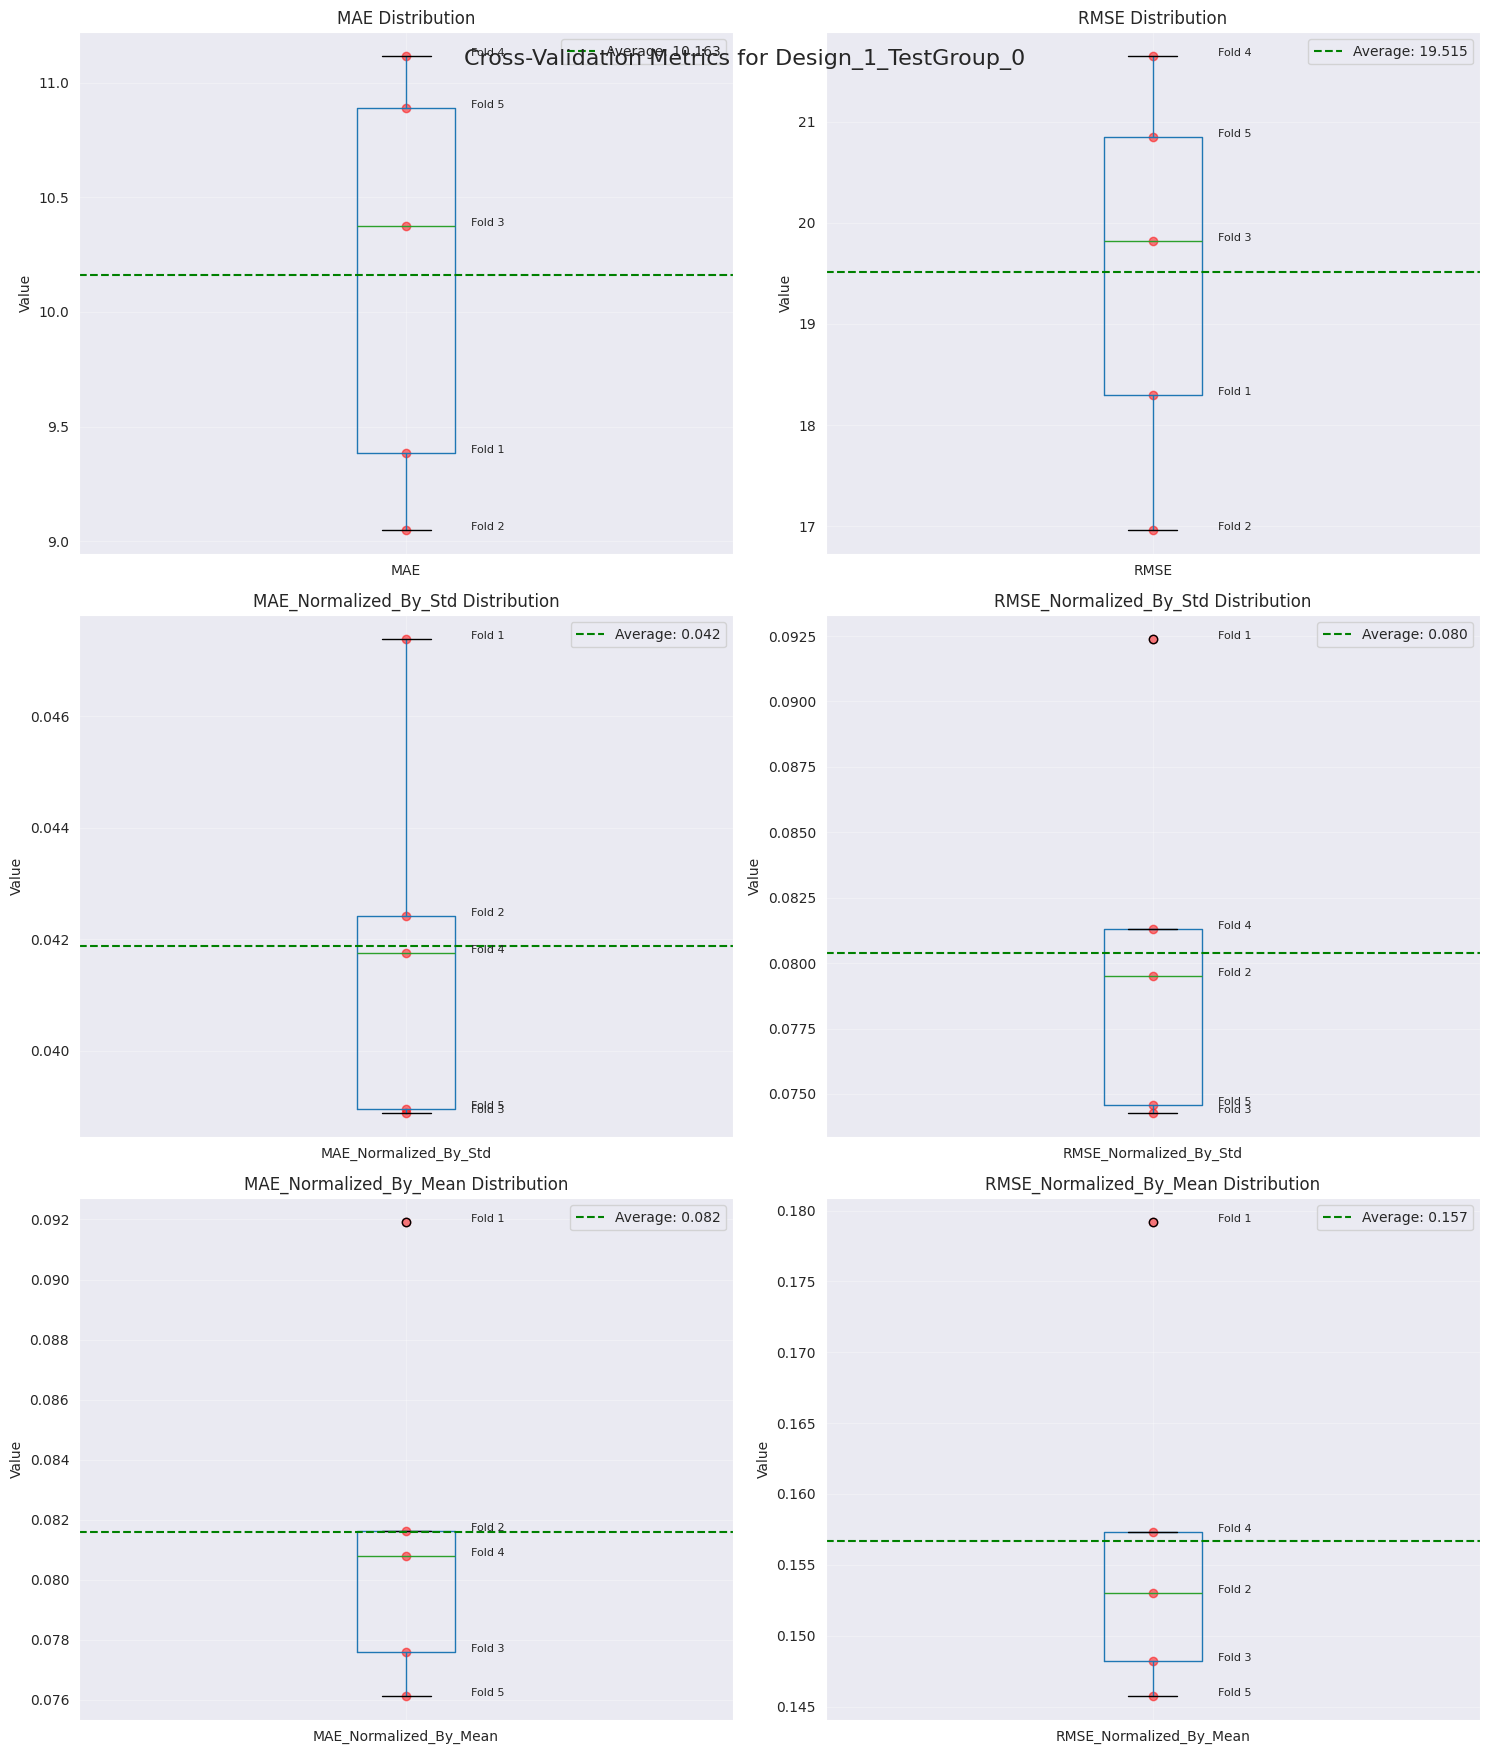

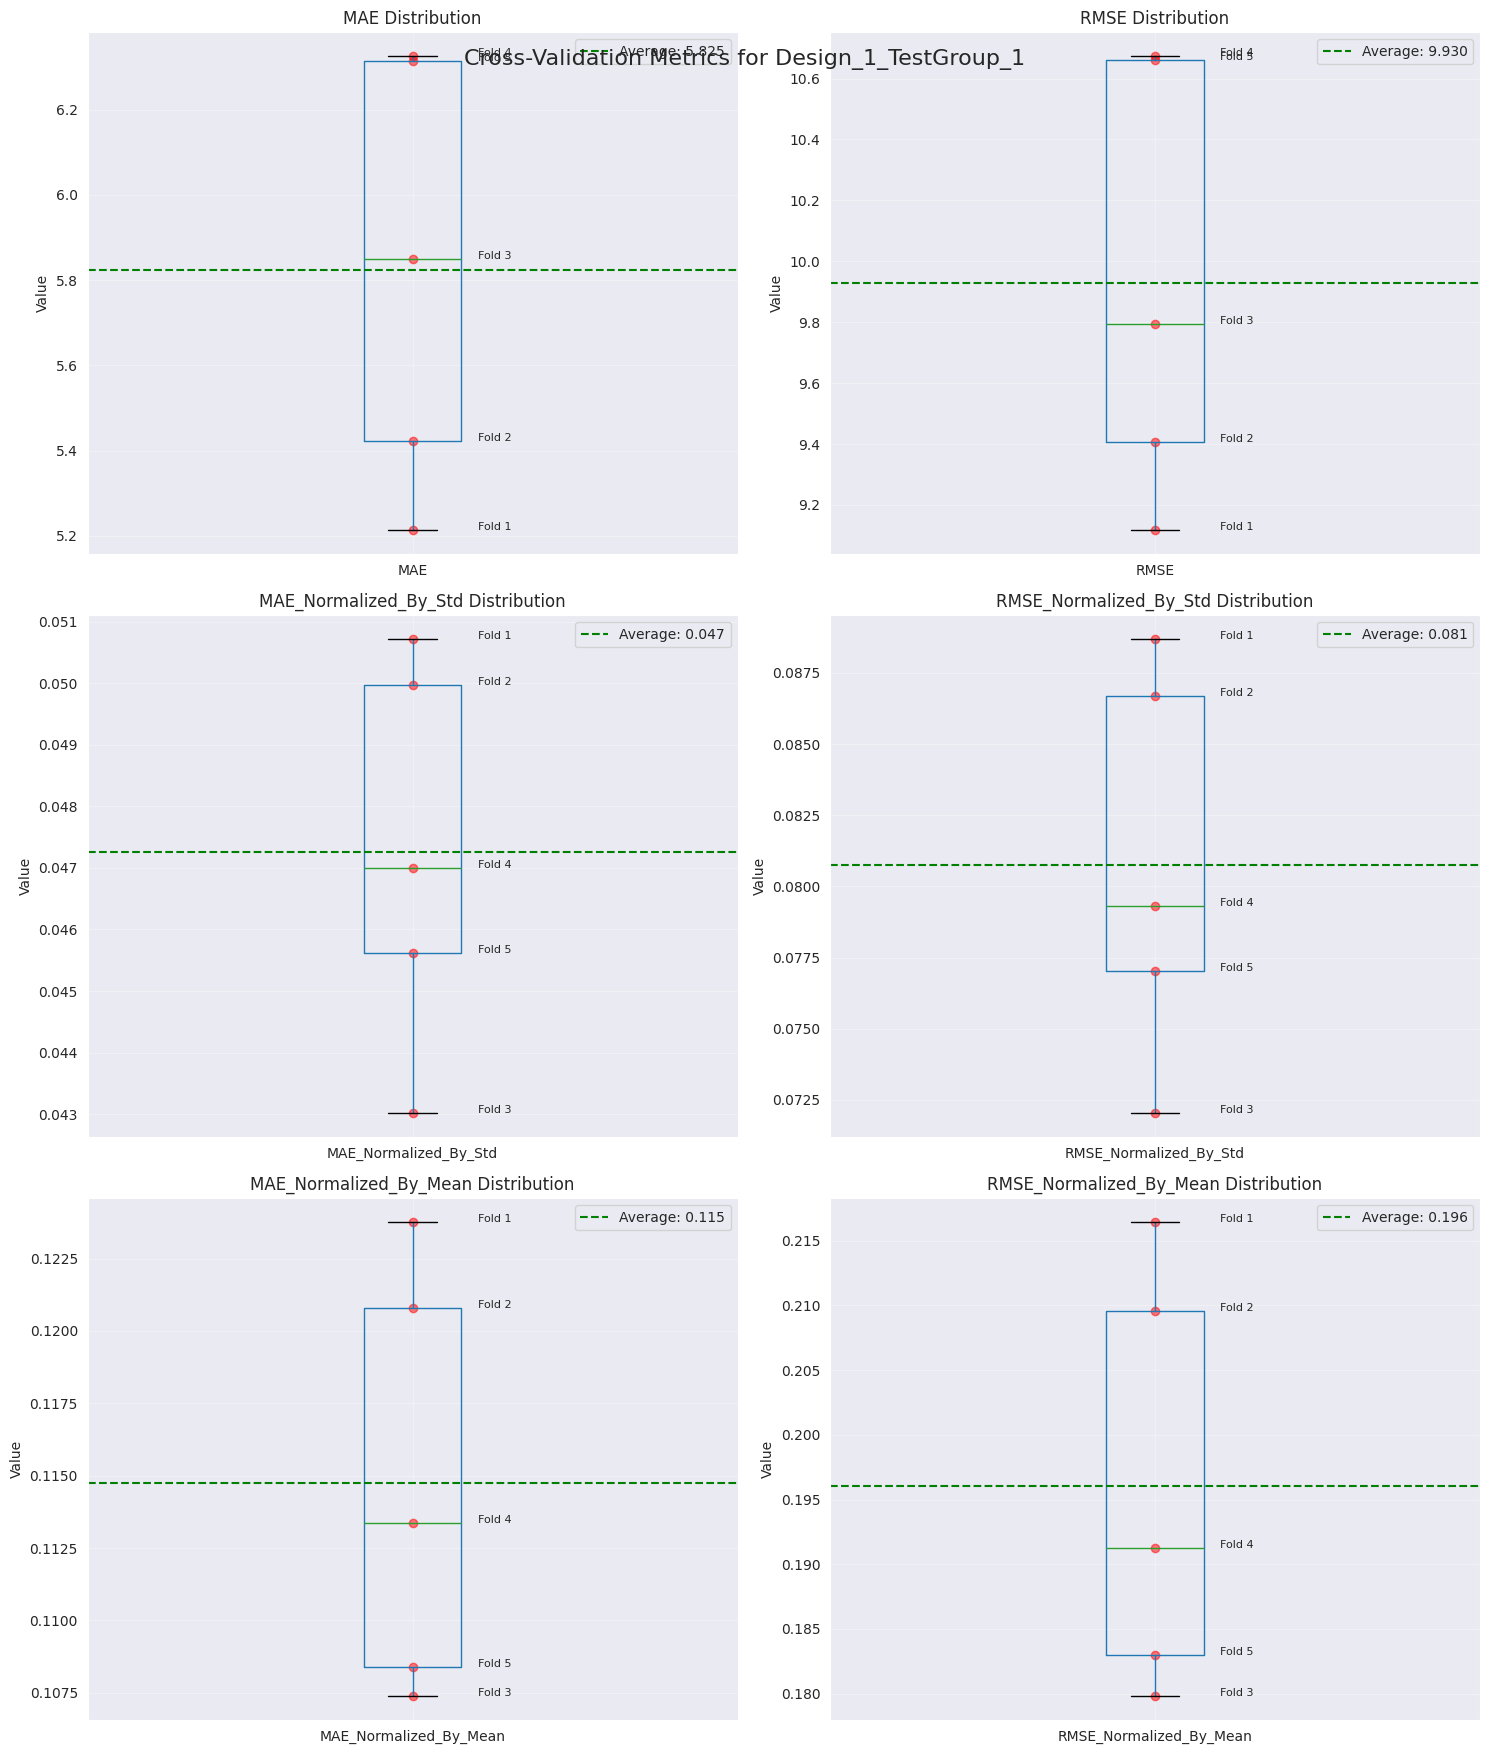

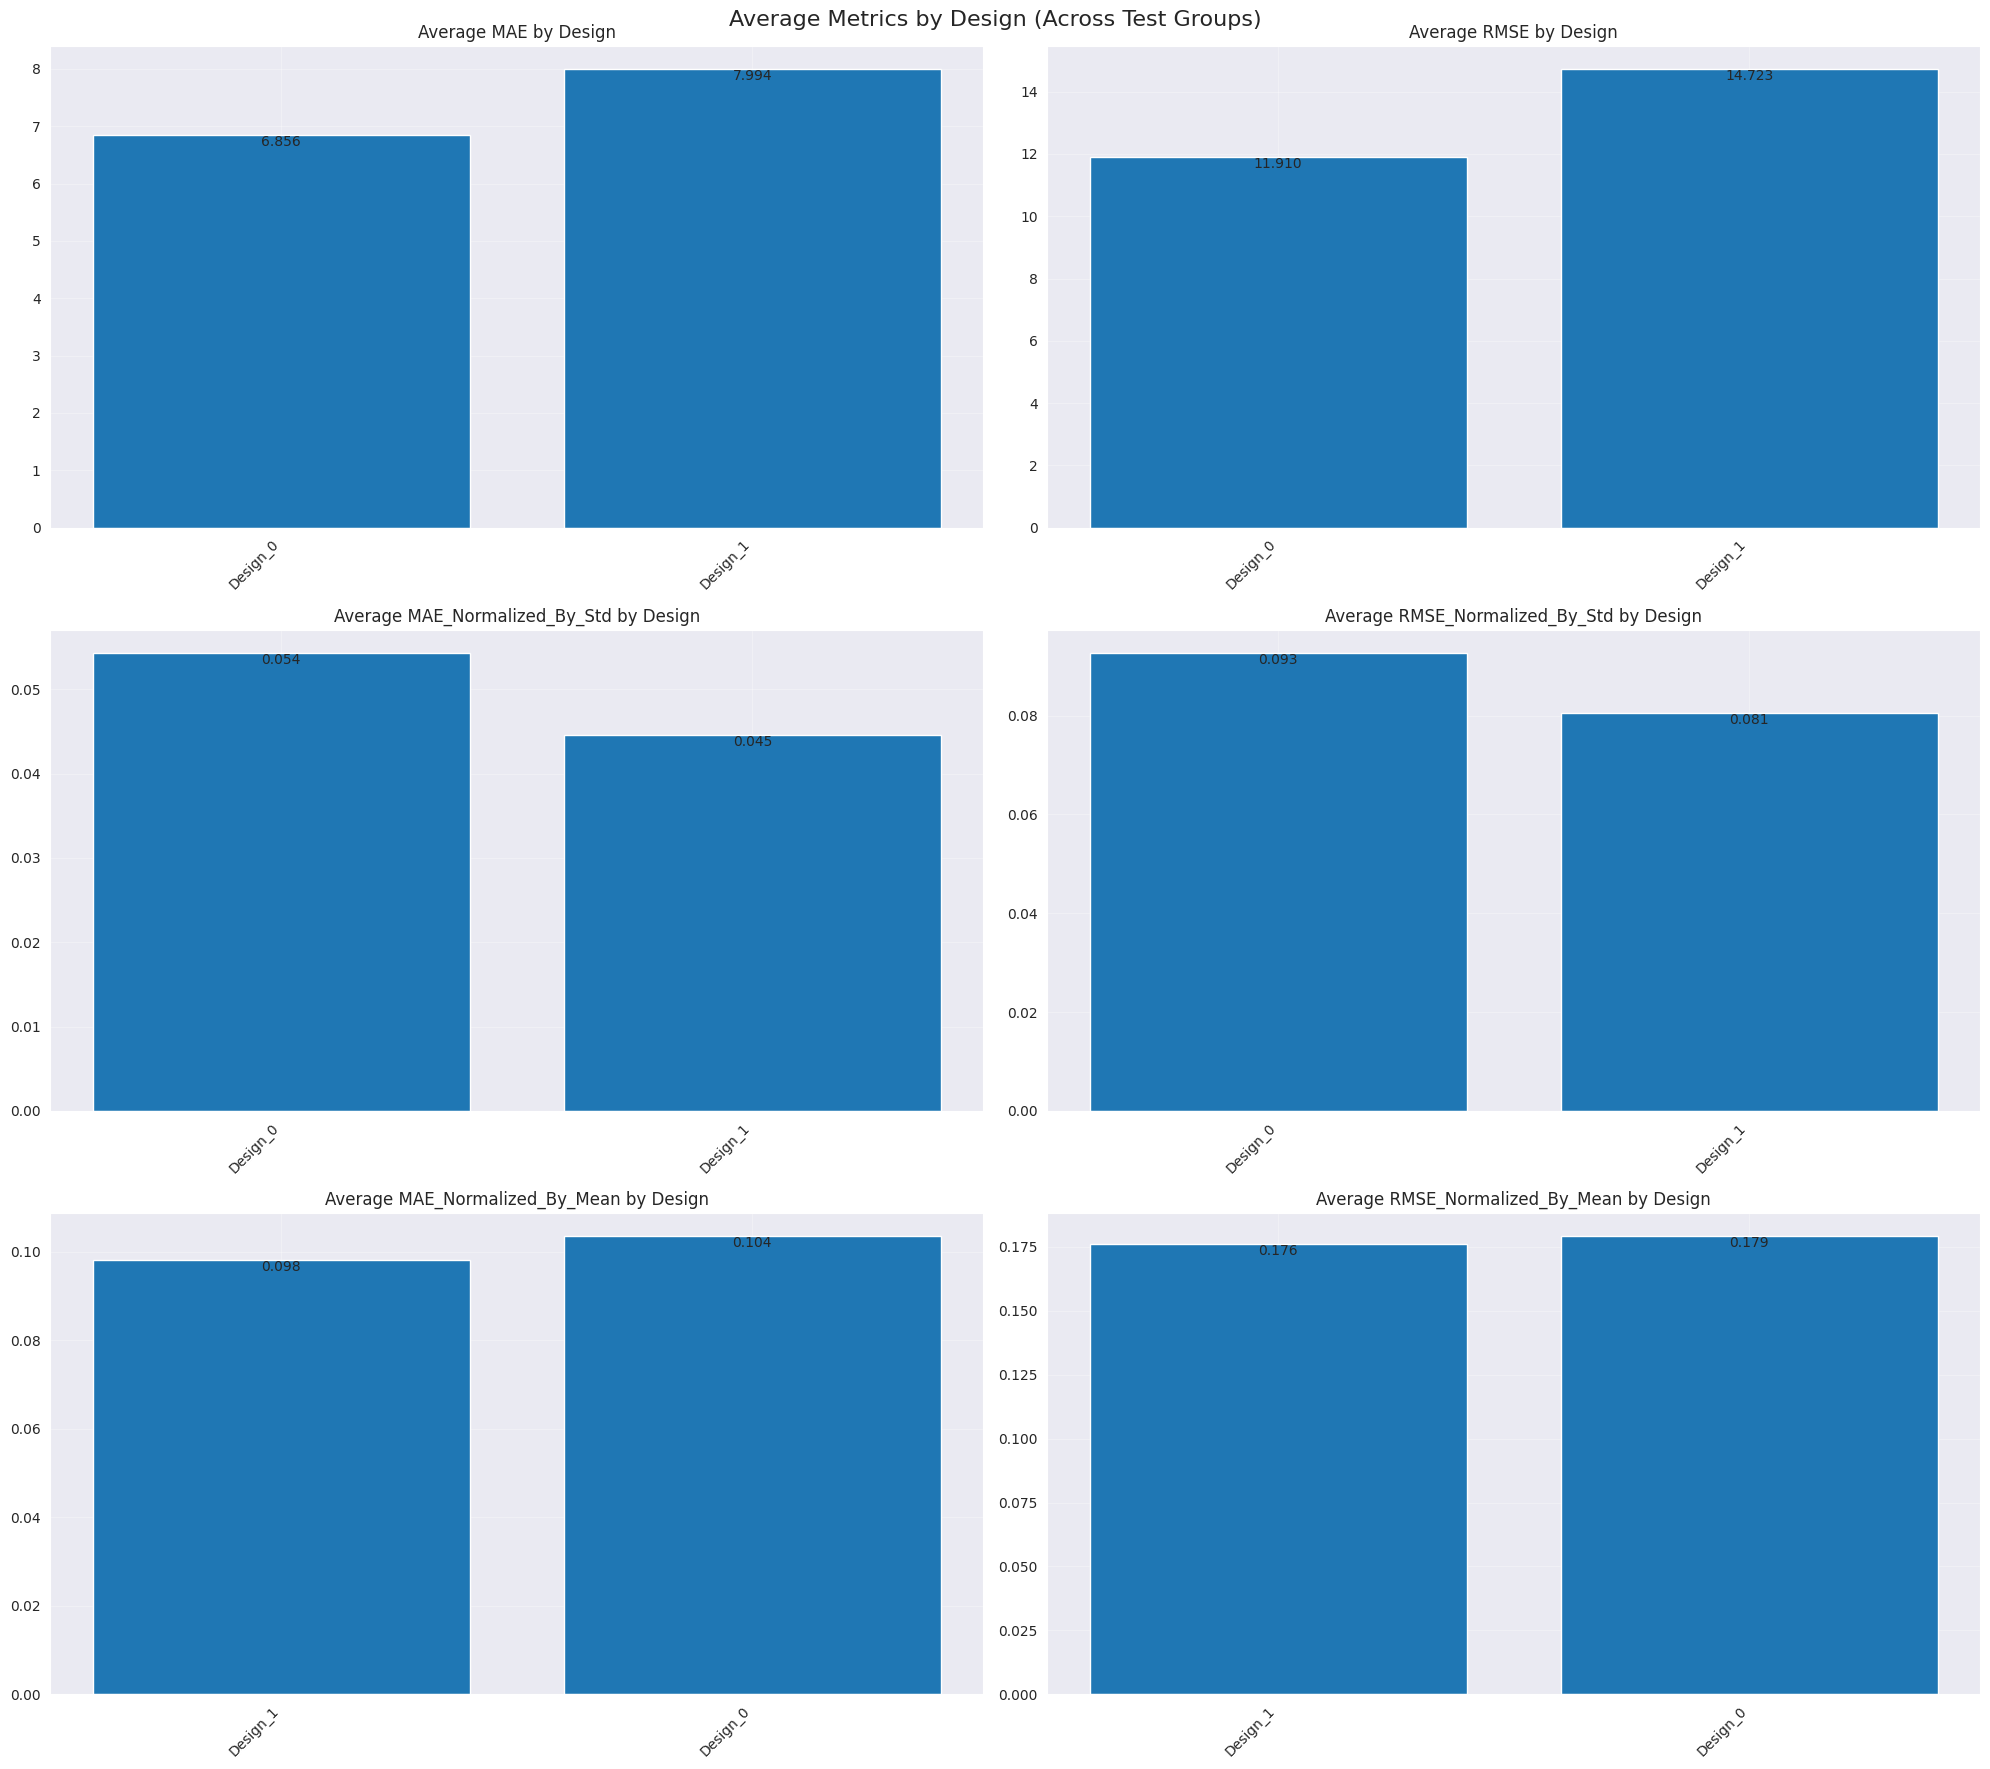

In [0]:
# 1. generate_cv_fit_plots: Performs time-based CV to assess how well control groups predict test groups
# 2. log_cv_fit_results: Logs results to MLflow with summary tables, visualizations and best designs

results = generate_cv_fit_plots(
    data=data.copy(),
    kpi=kpi,
    
    # indexes=indexes, # List[List[int]], optional 
    # List of design candidates, where each design is a list of indices corresponding
    # to positions in market_assignments_df after reset_index(). If not provided, designs
    # will be automatically grouped by control groups.
    
    market_assignments_df=mde_prc_df2, #DataFrame containing test and control groups for each index. 
    # Must have columns 'test_dmas' and 'control_dmas' 
    
    n_splits=5,
    random_state=42
)

# Log cv fit results 
log_cv_fit_results(results, run_name="cv_fit_analysis")